### Data Loading ###

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict, deque

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.model_selection import ( 
    train_test_split, StratifiedKFold, ParameterGrid
)
from sklearn.inspection import permutation_importance
import shap

In [3]:
df = pd.read_csv("Strikers.csv")
pd.set_option("display.max_columns", None)

df.head()
df.shape
df.info()
df.isna().mean().sort_values(ascending=False)
df.columns = df.columns.str.strip()
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 97 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Player                               212 non-null    object 
 1   Season                               212 non-null    object 
 2   Age                                  212 non-null    int64  
 3   Team                                 212 non-null    object 
 4   Goals                                212 non-null    float64
 5   Assist                               212 non-null    float64
 6   G+A                                  212 non-null    float64
 7   Non_penalty_goals                    212 non-null    float64
 8   Penalty_kicks-made                   212 non-null    float64
 9   Penalty_kicks_attempted              212 non-null    float64
 10  Penalty_kicks_missed                 212 non-null    float64
 11  Expected_goals                  

In [4]:
TARGET_COL = "Tier_league"  


counts = df[TARGET_COL].value_counts(dropna=False).sort_index()
props = (counts / len(df)).round(4)

target_dist = pd.DataFrame({
    "count": counts,
    "percent": (props * 100).round(2)
})

print("\nTarget distribution:")
display(target_dist)


majority_class = counts.idxmax()
majority_acc = counts.max() / len(df)

print(f"\nMajority class: {majority_class}")
print(f"Majority-class accuracy baseline: {majority_acc:.3f}")




Target distribution:


,count,percent
Tier_league,,
0,163,76.89
1,49,23.11



Majority class: 0
Majority-class accuracy baseline: 0.769


In [5]:
ID_COLS = ["Player", "Season", "Team", "Role"]
TARGET_COL = "Tier_league"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()


numeric_features = [c for c in numeric_cols if c != TARGET_COL]

print("Number of numeric features (pre-reduction):", len(numeric_features))


Number of numeric features (pre-reduction): 92


### EDA and Feature Scraping

In [7]:
# Variance and sparsity
var_df = pd.DataFrame({
    "variance": df[numeric_features].var(),
    "mean": df[numeric_features].mean(),
    "std": df[numeric_features].std(),
    "zero_ratio": (df[numeric_features] == 0).mean()
})

var_df = var_df.sort_values("variance")

display(var_df.head(15))
display(var_df.tail(15))


,variance,mean,std,zero_ratio
Own_goals,0.000000,0.000000,0.000000,1.000000
Penalty_kicks_conceded,0.000321,0.003302,0.017911,0.966981
Mistakes_leadto_shot,0.000620,0.006604,0.024894,0.933962
Penalty_kicks_missed,0.000781,0.008491,0.027940,0.915094
Red_cards,0.000820,0.008962,0.028632,0.910377
Penalty_kicks_won,0.003361,0.040094,0.057975,0.641509
Penalty_kicks-made,0.004642,0.042925,0.068130,0.660377
Penalty_kicks_attempted,0.006082,0.055660,0.077984,0.584906
Non_penalty_expGoals_perShot,0.006814,0.011745,0.082550,0.481132
Expected_assists,0.007308,0.093868,0.085488,0.278302


,variance,mean,std,zero_ratio
Tkld_During_Take_On%,166.755871,50.802358,12.913399,0.0
Carries/90,286.878134,51.254245,16.937477,0.0
Long_passes_Cmp%,312.102304,8.404245,17.666417,0.0
Passes_completition%,372.731032,31.053302,19.306243,0.0
Medium_pass_Cmp%,579.936698,15.844340,24.081875,0.0
Passes_toShot,597.401123,60.203774,24.441791,0.0
Short_passes_Cmp%,603.212546,22.639623,24.560386,0.0
Completed_medium_passes,621.610275,67.512264,24.932113,0.0
Completed_long_passes,626.259511,60.880189,25.025178,0.0
Completed_short_passes,1694.373807,43.605660,41.162772,0.0


In [8]:
# Removing low variance features
DROP_LOW_VARIANCE = [
    "Own_goals",
    "Penalty_kicks_conceded",
    "Mistakes_leadto_shot",
    "Penalty_kicks_missed",
    "Red_cards"
]

df_reduced = df.drop(columns=DROP_LOW_VARIANCE)
print("Shape after pruning:", df_reduced.shape)


Shape after pruning: (212, 92)


In [9]:
# Correlation with target inspection
TARGET_COL = "Tier_league"


num_features = [
    c for c in df_reduced.select_dtypes(include=[np.number]).columns
    if c != TARGET_COL
]


corr_target = (
    df_reduced[num_features]
    .corrwith(df_reduced[TARGET_COL])
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

corr_df = corr_target.to_frame(name="corr_with_target")
corr_df["abs_corr"] = corr_df["corr_with_target"].abs()

display(corr_df.head(20))
display(corr_df.tail(20))


,corr_with_target,abs_corr
G+A,0.440105,0.440105
xG+xAssisted_G,0.409575,0.409575
PassLive_lead_goal,0.403876,0.403876
PassLive_lead_shot_attempt,0.402112,0.402112
Attempted_short_passes,0.392925,0.392925
Non_penalty_expGoals+assisted_goals,0.383107,0.383107
Expected_assists,0.380538,0.380538
Passes_into_last3rd,0.377634,0.377634
Carries_into_final_third,0.376473,0.376473
Goals,0.371941,0.371941


,corr_with_target,abs_corr
Tackles_won,-0.117298,0.117298
Short_passes_Cmp%,0.107846,0.107846
Tackles_+Interc,-0.103777,0.103777
Yellow_cards,-0.102432,0.102432
Medium_pass_Cmp%,0.100985,0.100985
Shots_onTarget,0.095973,0.095973
Blocking_shots,-0.069939,0.069939
Dispossesd,-0.069793,0.069793
Completed_medium_passes,0.055692,0.055692
Offsides,-0.052612,0.052612


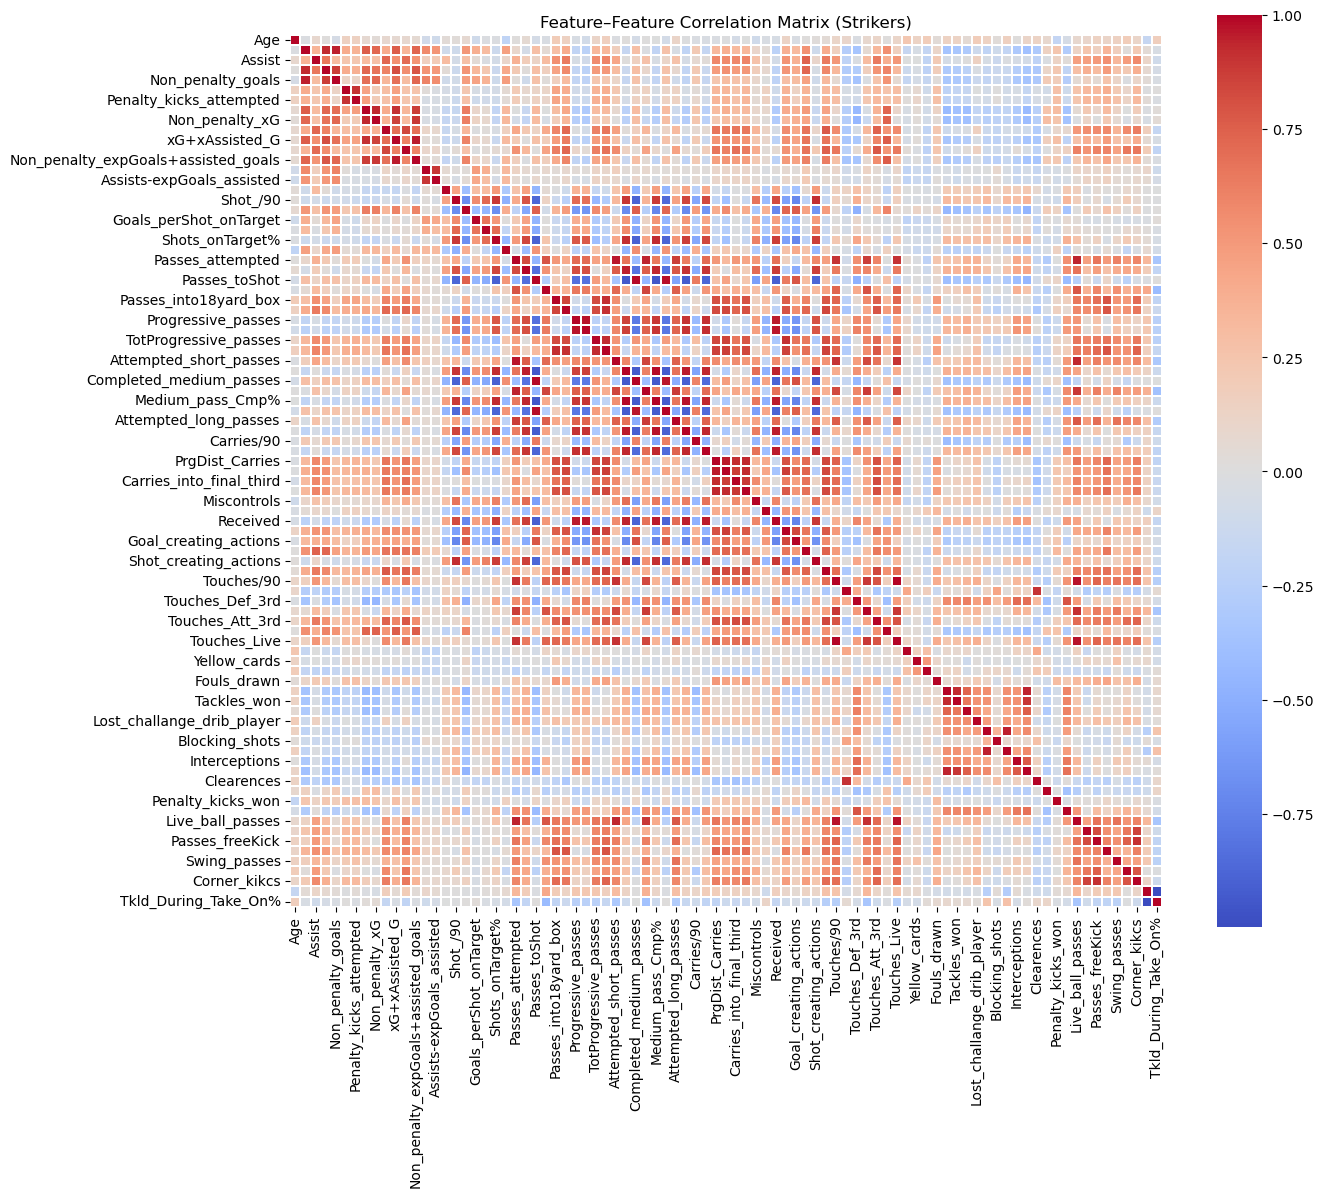

In [10]:
# Correlation matrix
num_features = [
    c for c in df_reduced.select_dtypes(include=[np.number]).columns
    if c != TARGET_COL
]

corr_matrix = df_reduced[num_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3
)
plt.title("Feature–Feature Correlation Matrix (Strikers)")
plt.tight_layout()
plt.show()


In [11]:
TARGET_COL = "Tier_league"

num_features = [
    c for c in df_reduced.select_dtypes(include=[np.number]).columns
    if c != TARGET_COL
]

corr = df_reduced[num_features].corr().abs()


THRESH = 0.85

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

pairs.columns = ["f1", "f2", "abs_corr"]

high_corr_pairs = pairs[pairs["abs_corr"] >= THRESH].sort_values(
    "abs_corr", ascending=False
)

print(f"Number of high-correlation pairs (|corr| ≥ {THRESH}):",
      len(high_corr_pairs))

display(high_corr_pairs.head(20))


Number of high-correlation pairs (|corr| ≥ 0.85): 122


,f1,f2,abs_corr
3218,Touches/90,Touches_Live,0.999976
3740,Succ_Takes_on%,Tkld_During_Take_On%,0.996583
1797,Passes_toShot,Completed_medium_passes,0.989854
2312,Short_passes_Cmp%,Medium_pass_Cmp%,0.989715
1800,Passes_toShot,Completed_long_passes,0.982875
2468,Medium_pass_Cmp%,Long_passes_Cmp%,0.974356
2030,Progressive_passes,TotDist_completed_passes,0.973649
3407,Touches_Live,Live_ball_passes,0.972085
3236,Touches/90,Live_ball_passes,0.971781
1670,Passes_attempted,Attempted_short_passes,0.966965


In [12]:
# Clusters of highly correlated features
def build_corr_clusters(pairs_df):
    graph = defaultdict(set)

    for f1, f2 in pairs_df[["f1", "f2"]].values:
        graph[f1].add(f2)
        graph[f2].add(f1)

    seen = set()
    clusters = []

    for node in graph:
        if node in seen:
            continue

        q = deque([node])
        comp = set([node])
        seen.add(node)

        while q:
            u = q.popleft()
            for v in graph[u]:
                if v not in seen:
                    seen.add(v)
                    comp.add(v)
                    q.append(v)

        clusters.append(sorted(comp))

    
    clusters = sorted(clusters, key=len, reverse=True)
    return clusters


clusters_graph = build_corr_clusters(high_corr_pairs)


In [13]:
for i, cluster in enumerate(clusters_graph, 1):
    print(f"\nGraph Cluster {i} (size={len(cluster)}):")
    for f in cluster:
        print(f"  - {f}")



Graph Cluster 1 (size=14):
  - Completed_long_passes
  - Completed_medium_passes
  - Long_passes_Cmp%
  - Medium_pass_Cmp%
  - Passes_completition%
  - Passes_toShot
  - Progressive_passes
  - Received
  - Short_passes_Cmp%
  - Shot_/90
  - Shot_creating_actions
  - Shots_onTarget%
  - TotDist_Carries
  - TotDist_completed_passes

Graph Cluster 2 (size=10):
  - Carries_10yards_forward
  - Carries_into18yard_box
  - Carries_into_final_third
  - Completed_short_passes
  - Crosses_into18yard_box
  - PassLive_lead_shot_attempt
  - Passes_into18yard_box
  - PrgDist_Carries
  - Prg_passes_received
  - TotProgressive_passes

Graph Cluster 3 (size=8):
  - Attempted_long_passes
  - Attempted_medium_passes
  - Attempted_short_passes
  - Live_ball_passes
  - Passes_attempted
  - Touches/90
  - Touches_Live
  - Touches_Mid_3rd

Graph Cluster 4 (size=4):
  - Expected_goals
  - Non_penalty_expGoals+assisted_goals
  - Non_penalty_xG
  - xG+xAssisted_G

Graph Cluster 5 (size=3):
  - G+A
  - Goals
  -

In [14]:
clustered_features = set(f for cluster in clusters_graph for f in cluster)

singleton_features = sorted(
    set(num_features) - clustered_features
)

print("Number non-redundant features:", len(singleton_features))


Number non-redundant features: 32


In [15]:
DROP_FEATURES = [
    
    "Completed_long_passes", "Completed_medium_passes",
    "Long_passes_Cmp%", "Medium_pass_Cmp%", "Short_passes_Cmp%",
    "Passes_completition%", "Passes_toShot", "Received",
    "Shot_/90", "Shots_onTarget%", "TotDist_Carries",
    "TotDist_completed_passes",

    
    "Carries_10yards_forward", "PrgDist_Carries",
    "Completed_short_passes", "Crosses_into18yard_box",
    "Passes_into18yard_box", "Prg_passes_received",
    "TotProgressive_passes", "PassLive_lead_shot_attempt",

    
    "Attempted_short_passes", "Attempted_medium_passes",
    "Attempted_long_passes", "Touches_Live",
    "Touches_Mid_3rd", "Live_ball_passes",
    "Passes_into_last3rd",

    
    "Expected_goals", "Non_penalty_xG",
    "Non_penalty_expGoals+assisted_goals",

    
    "Goals", "Non_penalty_goals",

    
    "Tackles_won", "Tackles_on_players", "Tackles_+Interc",

    
    "Dead_ball_pass", "Passes_freeKick",

    
    "Tkld_During_Take_On%",

    
    "Blocking_ball", "Blocking_pass",

    
    "Penalty_kicks_attempted",

    
    "Clearences", "Touches_Def_Pen",

    
    "Goals-Expected_goals", "Assists-expGoals_assisted"
]


In [16]:
df_strikers_final = df_reduced.drop(columns=DROP_FEATURES)

print("Final shape:", df_strikers_final.shape)





Final shape: (212, 47)


In [17]:
DROP = [
    "Blocking_shots",
    "Touches_Def_3rd",
    "Interceptions",
    "Tackles_on_dribblers",
    "Non_penalty_expGoals_perShot"
]

In [18]:
df_strikers_final = df_strikers_final.drop(columns=DROP)

print("Shape after pruning:", df_strikers_final.shape)


Shape after pruning: (212, 42)


In [19]:
df_strikers_final.to_csv("Strikers_model_ready.csv", index=False)


### Baseline models

In [21]:
X = df_strikers_final.drop(columns=ID_COLS + [TARGET_COL])
y = df_strikers_final[TARGET_COL]

print("Feature matrix shape:", X.shape)


Feature matrix shape: (212, 37)


Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (159, 37)
Test size: (53, 37)


In [24]:
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Custom functions

In [26]:
def hit_at_k(y_true, y_score, k=20):
    
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    k = min(k, len(y_true))
    idx = np.argsort(-y_score)[:k]
    return y_true[idx].sum() / max(1, y_true.sum())
def ndcg_at_k(y_true, y_score, k=20):
    
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    k = min(k, len(y_true))
    idx = np.argsort(-y_score)[:k]
    rel = y_true[idx]

    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    dcg = np.sum(rel * discounts)

    ideal_rel = np.sort(y_true)[::-1][:k]
    idcg = np.sum(ideal_rel * discounts)

    return dcg / idcg if idcg > 0 else 0.0

def evaluate_binary(y_true, y_prob, threshold=0.5, k=20):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        f"hit@{k}": hit_at_k(y_true, y_prob, k=k),
        f"ndcg@{k}": ndcg_at_k(y_true, y_prob, k=k),
    }

    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm

In [27]:
# Logistic Regression
log_reg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])


In [28]:
# Tree Classifier
xgb = Pipeline([
    ("preprocess", preprocess),  
    ("model", XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])


In [29]:
# Neural Network 
mlp = Pipeline([
    ("preprocess", preprocess),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-3,
        learning_rate_init=1e-3,
        early_stopping=True,
        n_iter_no_change=20,
        max_iter=2000,
        random_state=42
    ))
])


In [30]:
# Outputs
MODELS = {
    "Logistic": log_reg,
    "XGBoost": xgb,
    "MLP": mlp
}

results = []
cms = {}

for name, model in MODELS.items():
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    metrics, cm = evaluate_binary(y_test.values, y_prob, threshold=0.5, k=20)
    metrics["model"] = name
    results.append(metrics)
    cms[name] = cm

results_df = pd.DataFrame(results).set_index("model").sort_values("ndcg@20", ascending=False)
display(results_df)

print("\nConfusion matrices (threshold=0.5):")
for name, cm in cms.items():
    print(f"\n{name}\n{cm}")


,accuracy,precision,recall,f1,roc_auc,pr_auc,hit@20,ndcg@20
model,,,,,,,,
Logistic,0.698113,0.400,0.666667,0.5,0.741870,0.554938,0.666667,0.684998
MLP,0.830189,1.000,0.250000,0.4,0.662602,0.503442,0.500000,0.583226
XGBoost,0.811321,0.625,0.416667,0.5,0.705285,0.522395,0.500000,0.573581



Confusion matrices (threshold=0.5):

Logistic
[[29 12]
 [ 4  8]]

XGBoost
[[38  3]
 [ 7  5]]

MLP
[[41  0]
 [ 9  3]]


### Tuning Models ### 

In [32]:
# Setup
SEED = 42
TEST_SIZE = 0.25
K = 20

ID_COLS = ["Player", "Season", "Team", "Role"]
TARGET_COL = "Tier_league"

X = df_strikers_final.drop(columns=ID_COLS + [TARGET_COL])
y = df_strikers_final[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED
)

print("Feature matrix shape:", X.shape)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)



preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


def ndcg_at_k(y_true, y_score, k=20):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    k = min(k, len(y_true))

    idx = np.argsort(-y_score)[:k]
    rel = y_true[idx]

    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    dcg = np.sum(rel * discounts)

    ideal_rel = np.sort(y_true)[::-1][:k]
    idcg = np.sum(ideal_rel * discounts)

    return dcg / idcg if idcg > 0 else 0.0

def hit_at_k(y_true, y_score, k=20):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    k = min(k, len(y_true))
    idx = np.argsort(-y_score)[:k]
    return y_true[idx].sum() / max(1, y_true.sum())



def cv_rank_scores(model, X, y, k=20, n_splits=4, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    ndcgs, hits, rocs, pras = [], [], [], []

    for fold_i, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        y_prob = m.predict_proba(X_va)[:, 1]

        ndcgs.append(ndcg_at_k(y_va.values, y_prob, k=k))
        hits.append(hit_at_k(y_va.values, y_prob, k=k))
        rocs.append(roc_auc_score(y_va.values, y_prob))
        pras.append(average_precision_score(y_va.values, y_prob))

    return {
        "ndcg_mean": float(np.mean(ndcgs)),
        "ndcg_std": float(np.std(ndcgs)),
        "hit_mean": float(np.mean(hits)),
        "hit_std": float(np.std(hits)),
        "roc_mean": float(np.mean(rocs)),
        "pr_mean": float(np.mean(pras)),
    }
# Tuning
def tune_model(base_pipeline, param_grid, X, y, k=20, n_splits=4, seed=42, top_n=10):
    rows = []
    best_score = -1.0
    best_params = None

    for params in ParameterGrid(param_grid):
        model = clone(base_pipeline).set_params(**params)
        scores = cv_rank_scores(model, X, y, k=k, n_splits=n_splits, seed=seed)
        row = {**params, **scores}
        rows.append(row)

        if scores["ndcg_mean"] > best_score:
            best_score = scores["ndcg_mean"]
            best_params = params

    results = pd.DataFrame(rows).sort_values("ndcg_mean", ascending=False).reset_index(drop=True)
    print(f"Best NDCG@{k}: {best_score:.4f}")
    print("Best params:", best_params)
    display(results.head(top_n))
    return best_params, results


# Evaluating
def evaluate_on_test(model, X_train, y_train, X_test, y_test, k=20, threshold=0.5):
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        f"hit@{k}": hit_at_k(y_test.values, y_prob, k=k),
        f"ndcg@{k}": ndcg_at_k(y_test.values, y_prob, k=k),
    }
    cm = confusion_matrix(y_test, y_pred)
    return out, cm


pipe_log = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=4000,
        random_state=SEED
    ))
])


pipe_xgb = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED
    ))
])

pipe_mlp = Pipeline([
    ("preprocess", preprocess),
    ("model", MLPClassifier(
        early_stopping=True,
        n_iter_no_change=20,
        max_iter=4000,
        random_state=SEED
    ))
])

# Grid search space

grid_log = {
    "model__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    "model__class_weight": [None, "balanced"]
}


grid_xgb = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.9, 1.0],
    "model__min_child_weight": [1, 5],
    "model__reg_lambda": [1.0, 5.0]
}

grid_mlp = {
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128,)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [1e-5, 1e-4, 1e-3],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3]
}


print("\n===== Tuning Logistic (CV NDCG@{}) =====".format(K))
best_log_params, log_results = tune_model(pipe_log, grid_log, X_train, y_train, k=K, n_splits=4, seed=SEED)

print("\n===== Tuning XGBoost (CV NDCG@{}) =====".format(K))
best_xgb_params, xgb_results = tune_model(pipe_xgb, grid_xgb, X_train, y_train, k=K, n_splits=4, seed=SEED)

print("\n===== Tuning MLP (CV NDCG@{}) =====".format(K))
best_mlp_params, mlp_results = tune_model(pipe_mlp, grid_mlp, X_train, y_train, k=K, n_splits=4, seed=SEED)


best_log = clone(pipe_log).set_params(**best_log_params)
best_xgb = clone(pipe_xgb).set_params(**best_xgb_params)
best_mlp = clone(pipe_mlp).set_params(**best_mlp_params)

final_rows = []
final_cms = {}

for name, model in [
    ("Logistic_tuned", best_log),
    ("XGBoost_tuned", best_xgb),
    ("MLP_tuned", best_mlp),
]:
    metrics, cm = evaluate_on_test(model, X_train, y_train, X_test, y_test, k=K, threshold=0.5)
    metrics["model"] = name
    final_rows.append(metrics)
    final_cms[name] = cm

final_df = pd.DataFrame(final_rows).set_index("model").sort_values(f"ndcg@{K}", ascending=False)
print("\n===== TEST RESULTS (Locked Params) =====")
display(final_df)

print("\nConfusion matrices (threshold=0.5):")
for name, cm in final_cms.items():
    print(f"\n{name}\n{cm}")


Feature matrix shape: (212, 37)
Train size: (159, 37)
Test size: (53, 37)

===== Tuning Logistic (CV NDCG@20) =====
Best NDCG@20: 0.8690
Best params: {'model__C': 0.1, 'model__class_weight': 'balanced'}


,model__C,model__class_weight,ndcg_mean,ndcg_std,hit_mean,hit_std,roc_mean,pr_mean
0,0.10,balanced,0.868976,0.030431,0.894444,0.070929,0.861490,0.751680
1,0.30,balanced,0.862010,0.030410,0.894444,0.070929,0.860848,0.738912
2,0.30,None,0.853578,0.046573,0.866667,0.087489,0.853041,0.744348
3,0.05,None,0.846213,0.031550,0.838889,0.093459,0.851428,0.752904
4,3.00,None,0.845700,0.034640,0.866667,0.087489,0.852458,0.726827
5,1.00,balanced,0.845362,0.045607,0.866667,0.087489,0.859310,0.730974
6,3.00,balanced,0.844362,0.035719,0.866667,0.087489,0.849740,0.723017
7,0.05,balanced,0.841369,0.030380,0.838889,0.093459,0.855066,0.747405
8,0.10,None,0.840356,0.033841,0.838889,0.093459,0.851768,0.743293
9,1.00,None,0.836344,0.035443,0.838889,0.093459,0.857706,0.740028



===== Tuning XGBoost (CV NDCG@20) =====
Best NDCG@20: 0.8437
Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_child_weight': 5, 'model__n_estimators': 200, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}


,model__colsample_bytree,model__learning_rate,model__max_depth,model__min_child_weight,model__n_estimators,model__reg_lambda,model__subsample,ndcg_mean,ndcg_std,hit_mean,hit_std,roc_mean,pr_mean
0,1.0,0.1,3,5,200,1.0,0.8,0.843743,0.066346,0.838889,0.093459,0.838522,0.744930
1,1.0,0.1,2,5,200,1.0,0.8,0.843743,0.066346,0.838889,0.093459,0.838522,0.744930
2,1.0,0.1,4,5,200,1.0,0.8,0.843743,0.066346,0.838889,0.093459,0.838522,0.744930
3,1.0,0.1,5,5,200,1.0,0.8,0.843743,0.066346,0.838889,0.093459,0.838522,0.744930
4,0.7,0.1,3,5,400,1.0,0.8,0.840188,0.052845,0.838889,0.093459,0.842010,0.740591
5,0.7,0.1,2,5,400,1.0,0.8,0.840188,0.052845,0.838889,0.093459,0.842010,0.740591
6,0.7,0.1,5,5,400,1.0,0.8,0.840188,0.052845,0.838889,0.093459,0.842010,0.740591
7,0.7,0.1,4,5,400,1.0,0.8,0.840188,0.052845,0.838889,0.093459,0.842010,0.740591
8,1.0,0.1,4,5,400,5.0,0.8,0.837968,0.063389,0.838889,0.093459,0.836947,0.732923
9,1.0,0.1,5,5,400,5.0,0.8,0.837968,0.063389,0.838889,0.093459,0.836947,0.732923



===== Tuning MLP (CV NDCG@20) =====
Best NDCG@20: 0.8263
Best params: {'model__activation': 'tanh', 'model__alpha': 1e-05, 'model__hidden_layer_sizes': (128,), 'model__learning_rate_init': 0.001}


,model__activation,model__alpha,model__hidden_layer_sizes,model__learning_rate_init,ndcg_mean,ndcg_std,hit_mean,hit_std,roc_mean,pr_mean
0,tanh,0.00100,"(128,)",0.0010,0.826314,0.027745,0.863889,0.093087,0.827124,0.682768
1,tanh,0.00001,"(128,)",0.0010,0.826314,0.027745,0.863889,0.093087,0.827124,0.682768
2,tanh,0.00010,"(128,)",0.0010,0.826314,0.027745,0.863889,0.093087,0.827124,0.682768
3,tanh,0.00001,"(128,)",0.0005,0.825465,0.026115,0.863889,0.093087,0.823513,0.680047
4,tanh,0.00010,"(128,)",0.0005,0.825465,0.026115,0.863889,0.093087,0.823513,0.680047
5,tanh,0.00100,"(128,)",0.0005,0.825465,0.026115,0.863889,0.093087,0.823513,0.680047
6,relu,0.00010,"(128,)",0.0010,0.816155,0.047203,0.808333,0.094730,0.826189,0.713272
7,relu,0.00001,"(128,)",0.0010,0.816155,0.047203,0.808333,0.094730,0.826189,0.713272
8,relu,0.00100,"(128,)",0.0010,0.816155,0.047203,0.808333,0.094730,0.826189,0.713272
9,relu,0.00001,"(128,)",0.0005,0.804474,0.046494,0.808333,0.094730,0.803378,0.683684



===== TEST RESULTS (Locked Params) =====


,accuracy,precision,recall,f1,roc_auc,pr_auc,hit@20,ndcg@20
model,,,,,,,,
MLP_tuned,0.603774,0.320000,0.666667,0.432432,0.743902,0.567529,0.666667,0.692064
XGBoost_tuned,0.849057,0.833333,0.416667,0.555556,0.693089,0.555190,0.583333,0.635167
Logistic_tuned,0.660377,0.350000,0.583333,0.437500,0.745935,0.513047,0.583333,0.607985



Confusion matrices (threshold=0.5):

Logistic_tuned
[[28 13]
 [ 5  7]]

XGBoost_tuned
[[40  1]
 [ 7  5]]

MLP_tuned
[[24 17]
 [ 4  8]]


### Best models ###

In [34]:
# Scouting outputs with best models
X_full = df_strikers_final.drop(columns=ID_COLS + [TARGET_COL])
y_full = df_strikers_final[TARGET_COL]



log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.05,
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ))
])

mlp_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="tanh",
        alpha=1e-5,
        learning_rate_init=1e-3,
        max_iter=2000,
        random_state=SEED
    ))
])

xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.03,
        subsample=1.0,
        colsample_bytree=0.7,
        min_child_weight=1,
        reg_lambda=5.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED
    ))
])


log_pipe.fit(X_full, y_full)
mlp_pipe.fit(X_full, y_full)
xgb_pipe.fit(X_full, y_full)


df_scout = df_strikers_final[ID_COLS].copy()

df_scout["p_tier_logistic"] = log_pipe.predict_proba(X_full)[:, 1]
df_scout["p_tier_mlp"] = mlp_pipe.predict_proba(X_full)[:, 1]
df_scout["p_tier_xgb"] = xgb_pipe.predict_proba(X_full)[:, 1]


df_scout["p_tier_mean"] = (
    df_scout["p_tier_logistic"]
    + df_scout["p_tier_mlp"]
    + df_scout["p_tier_xgb"]
) / 3


df_scout = df_scout.sort_values(
    by="p_tier_xgb",   # main scouting signal
    ascending=False
).reset_index(drop=True)


df_scout.to_csv("Strikers_scouting_table.csv", index=False)

df_scout.head(20)


,Player,Season,Team,Role,p_tier_logistic,p_tier_mlp,p_tier_xgb,p_tier_mean
0,Kylian Mbappé,2021-2022,Paris S-G,CF,0.992921,0.999985,0.925022,0.972643
1,Neymar,2017-2018,Paris S-G,SS,0.998286,0.999632,0.923833,0.973917
2,Kylian Mbappé,2020-2021,Paris S-G,CF,0.990432,0.999970,0.919407,0.969936
3,Memphis,2017-2018,Lyon,CF,0.865483,0.999531,0.913754,0.926256
4,Memphis,2020-2021,Lyon,CF,0.911636,0.999933,0.905484,0.939018
5,Neymar,2019-2020,Paris S-G,SS,0.994145,0.999957,0.894124,0.962742
6,Kylian Mbappé,2018-2019,Paris S-G,CF,0.995313,0.999456,0.888358,0.961043
7,Memphis,2018-2019,Lyon,CF,0.803091,0.999406,0.880160,0.894219
8,Kylian Mbappé,2017-2018,2 Teams,CF,0.976016,0.999544,0.872764,0.949442
9,Kylian Mbappé,2019-2020,Paris S-G,CF,0.997060,0.999793,0.855211,0.950688


### Permutation and SHAP 

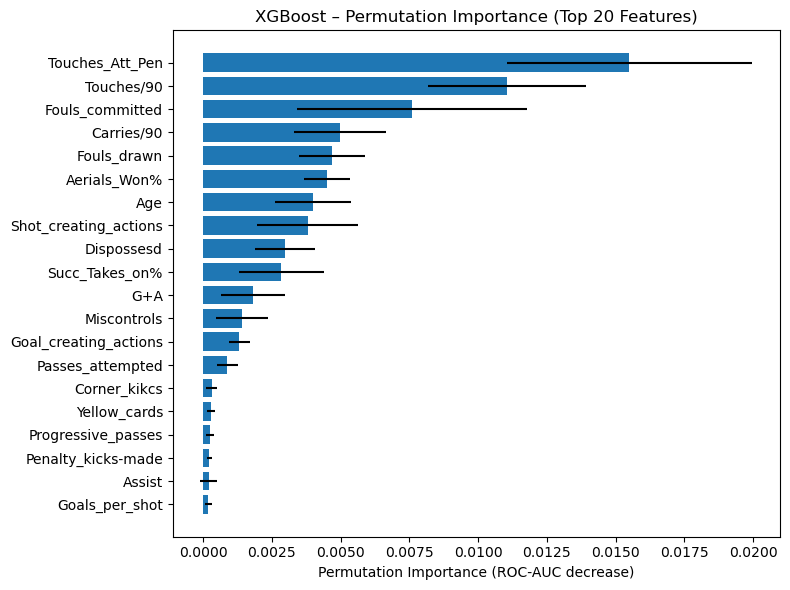

,feature,importance_mean,importance_std
23,Touches_Att_Pen,0.015504,0.004471
21,Touches/90,0.011043,0.002865
26,Fouls_committed,0.007596,0.004197
13,Carries/90,0.004983,0.001666
27,Fouls_drawn,0.004687,0.001186
24,Aerials_Won%,0.004495,0.000833
0,Age,0.004002,0.001374
20,Shot_creating_actions,0.003806,0.001833
17,Dispossesd,0.002971,0.001084
36,Succ_Takes_on%,0.002846,0.001531


In [36]:
# Permutation setup
perm = permutation_importance(
    xgb_pipe,
    X_full,
    y_full,
    n_repeats=30,
    random_state=SEED,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X_full.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

# Keep top N
TOP_N = 20
perm_top = perm_df.head(TOP_N)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(
    perm_top["feature"][::-1],
    perm_top["importance_mean"][::-1],
    xerr=perm_top["importance_std"][::-1]
)
plt.xlabel("Permutation Importance (ROC-AUC decrease)")
plt.title("XGBoost – Permutation Importance (Top 20 Features)")
plt.tight_layout()
plt.show()

perm_top


In [37]:
# Shap analysis setup
xgb_model = xgb_pipe.named_steps["model"]


X_processed = xgb_pipe.named_steps["imputer"].transform(X_full)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_processed)


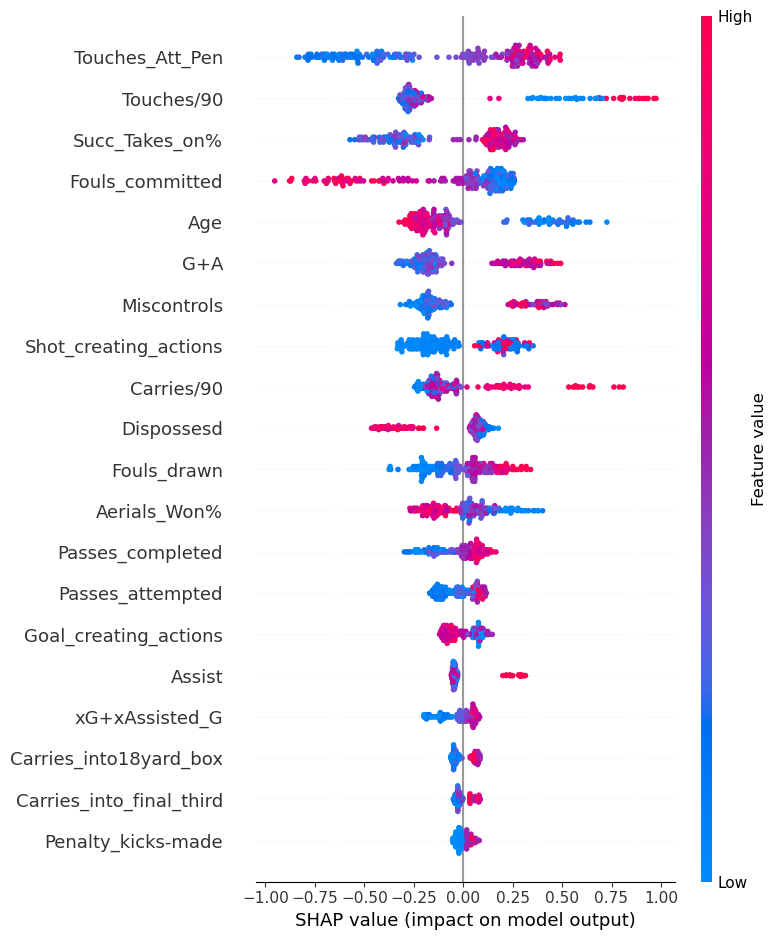

In [38]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=X_full.columns,
    max_display=20,
    show=True
)


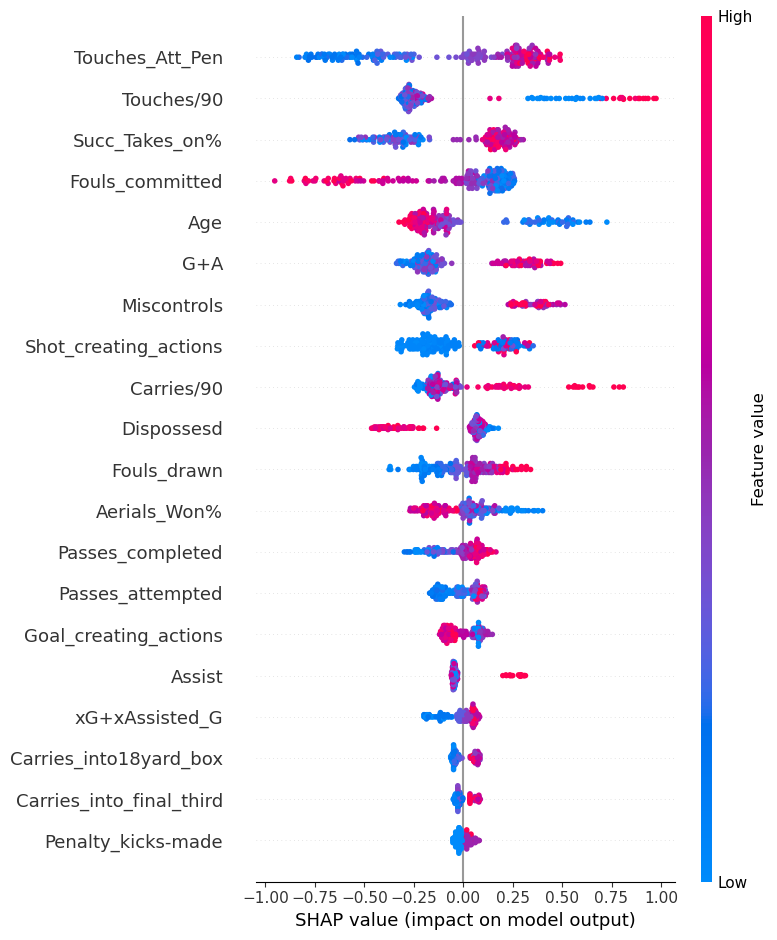

In [39]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=X_full.columns,
    max_display=20,
    show=True
)


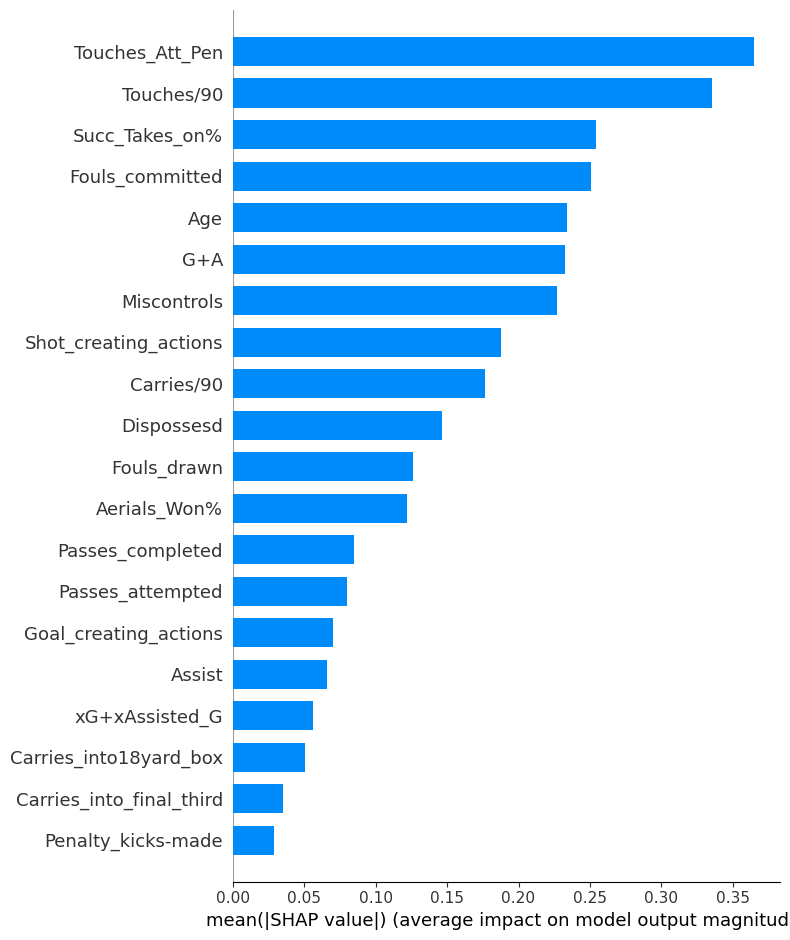

In [40]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=X_full.columns,
    plot_type="bar",
    max_display=20,
    show=True
)


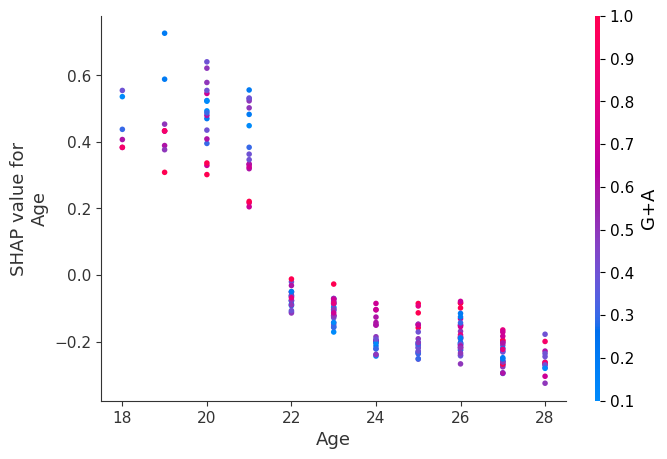

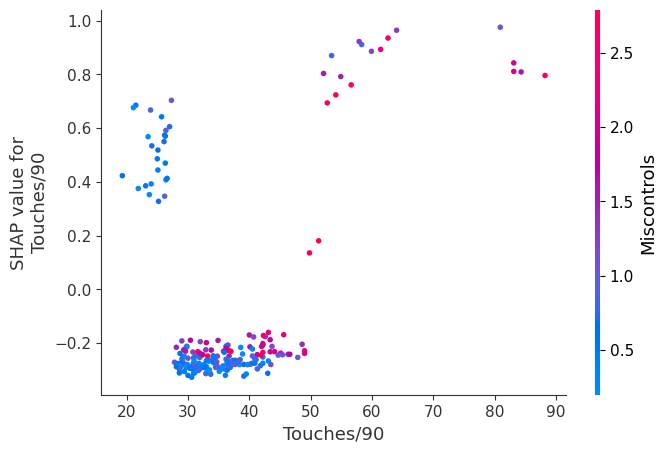

In [41]:
# Plotting
shap.dependence_plot(
    "Age",
    shap_values,
    X_processed,
    feature_names=X_full.columns
)

shap.dependence_plot(
    "Touches/90",
    shap_values,
    X_processed,
    feature_names=X_full.columns
)
